In [ ]:
# ============================================================
# ANN MODEL - CUSTOMER CHURN CLASSIFICATION
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve
)

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

In [ ]:
#upload the dataset file
from google.colab import files

uploaded = files.upload()

Saving final_train_processed.csv to final_train_processed.csv


In [ ]:
#read the csv file and print first 5 rows

df = pd.read_csv("final_train_processed.csv")

print("Dataset Shape:", df.shape)

display(df.head())

print("\nTarget Distribution:")
print(df["Exited"].value_counts())

Dataset Shape: (12282, 18)


,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,BalanceSalaryRatio,TenureByAge,BalancePerProduct,ProductsPerTenure,ActiveWithCard,IsZeroBalance,Exited
0,-1.559275,1,2.203528,0.702996,0.334468,-0.772148,1,0,1.515320,1,0,-0.031847,-0.195976,0.598022,-0.679976,0,0,1
1,-1.887838,1,-1.499687,-0.680357,1.223621,-0.772148,1,1,0.647485,0,0,-0.029089,-0.188644,1.549762,-0.310125,1,0,0
2,-0.162883,1,-1.605493,1.394672,-1.341260,0.878882,1,1,-1.606137,0,1,-0.034391,2.655934,-1.195658,-0.458065,1,1,0
3,-0.532516,1,-0.653238,-1.717871,0.367751,-0.772148,0,1,-0.995484,0,1,-0.023161,-1.530426,0.633648,1.908983,0,0,0
4,-0.696798,0,-0.018401,-0.680357,0.460363,-0.772148,1,1,1.593959,1,0,-0.031721,-0.658268,0.732779,-0.310125,1,0,1



Target Distribution:
Exited
1    6141
0    6141
Name: count, dtype: int64


In [ ]:
#seperate the feature and the target
# y is target column and x is all the other columns
X = df.drop("Exited", axis=1)
y = df["Exited"]

print("Features:", X.shape)
print("Target:", y.shape)

Features: (12282, 17)
Target: (12282,)


Train/Test split

In [ ]:
#split data into training and test purpose
#we assigned 20% data to testing
#stratify is used to preserves the class distribution of the target variable
#random state makes traintest split reproducible
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training:", X_train.shape)
print("Testing :", X_test.shape)

Training: (9825, 17)
Testing : (2457, 17)


Create validation set

In [ ]:
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    random_state=42,
    stratify=y_train
)

print("Training   :", X_train_final.shape)
print("Validation :", X_val.shape)
print("Testing    :", X_test.shape)

Training   : (7860, 17)
Validation : (1965, 17)
Testing    : (2457, 17)


ANN Hyperparameter Tuning

In [ ]:
ann_configs = [
    {
        "name": "ANN_V1",
        "hidden_layers": [32, 16],
        "dropout": 0.20,
        "learning_rate": 0.001,
        "batch_size": 32
    },

    {
        "name": "ANN_V2",
        "hidden_layers": [64, 32],
        "dropout": 0.30,
        "learning_rate": 0.001,
        "batch_size": 32
    },

    {
        "name": "ANN_V3",
        "hidden_layers": [128, 64, 32],
        "dropout": 0.30,
        "learning_rate": 0.0005,
        "batch_size": 64
    }
]

print("Number of ANN varieties:", len(ann_configs))

Number of ANN varieties: 3


In [ ]:
#ReLU introduces non linearity
#allow ann to learn complex relationships
#every layer recieves information from previous layer
#output layer  has 1 neuron bcz this is binary classification problem
#sigmoid function turn output between 0-1
def create_ann(config, input_dim):

    model = Sequential()

    # First hidden layer
    model.add(
        Dense(
            config["hidden_layers"][0],
            activation="relu",
            input_shape=(input_dim,)
        )
    )

    model.add(
        Dropout(config["dropout"])
    )

    # Remaining hidden layers
    for neurons in config["hidden_layers"][1:]:

        model.add(
            Dense(
                neurons,
                activation="relu"
            )
        )

        model.add(
            Dropout(config["dropout"])
        )

    # Output layer
    model.add(
        Dense(
            1,
            activation="sigmoid"
        )
    )

    optimizer = keras.optimizers.Adam(
        learning_rate=config["learning_rate"]
    )

    model.compile(
        optimizer=optimizer,
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [ ]:
#accuracy-proportion of correct predictions.
#precision-the model predicted as churned, how many actually churned?
#recall-who actually churned, how many did the model successfully identify?
#F1 Score-combines precision and recall into one measure
ann_results = []
ann_models = {}
ann_histories = {}

for config in ann_configs:

    print("\n========================================")
    print("Training:", config["name"])
    print("========================================")

    tf.keras.backend.clear_session()

    model = create_ann(
        config,
        X_train_final.shape[1]
    )
#Early stopping is a technique used to stop training when the validation performance stops improving
    early_stopping = EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True
    )

    history = model.fit(
        X_train_final,
        y_train_final,

        validation_data=(
            X_val,
            y_val
        ),

        epochs=100,
        batch_size=config["batch_size"],

        callbacks=[early_stopping],

        verbose=0
    )

    # Validation probabilities
    y_val_prob = model.predict(
        X_val,
        verbose=0
    ).ravel()

    # Convert probability to class
    y_val_pred = (
        y_val_prob >= 0.5
    ).astype(int)

    accuracy = accuracy_score(
        y_val,
        y_val_pred
    )

    precision = precision_score(
        y_val,
        y_val_pred,
        zero_division=0
    )

    recall = recall_score(
        y_val,
        y_val_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_val,
        y_val_pred,
        zero_division=0
    )

    roc_auc = roc_auc_score(
        y_val,
        y_val_prob
    )

    ann_results.append({
        "Model": config["name"],
        "Hidden_Layers": str(config["hidden_layers"]),
        "Dropout": config["dropout"],
        "Learning_Rate": config["learning_rate"],
        "Batch_Size": config["batch_size"],
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1_Score": f1,
        "ROC_AUC": roc_auc
    })

    ann_models[config["name"]] = model
    ann_histories[config["name"]] = history

    print("Accuracy :", round(accuracy, 4))
    print("Precision:", round(precision, 4))
    print("Recall   :", round(recall, 4))
    print("F1 Score :", round(f1, 4))
    print("ROC-AUC  :", round(roc_auc, 4))


Training: ANN_V1


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Accuracy : 0.7975
Precision: 0.7746
Recall   : 0.8393
F1 Score : 0.8057
ROC-AUC  : 0.8771

Training: ANN_V2


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Accuracy : 0.798
Precision: 0.7828
Recall   : 0.825
F1 Score : 0.8034
ROC-AUC  : 0.8876

Training: ANN_V3


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Accuracy : 0.8173
Precision: 0.7989
Recall   : 0.8484
F1 Score : 0.8229
ROC-AUC  : 0.8994


Compare ANN varieties

In [ ]:
ann_results_df = pd.DataFrame(
    ann_results
)

ann_results_df = ann_results_df.sort_values(
    "ROC_AUC",
    ascending=False
).reset_index(drop=True)

display(ann_results_df)

,Model,Hidden_Layers,Dropout,Learning_Rate,Batch_Size,Accuracy,Precision,Recall,F1_Score,ROC_AUC
0,ANN_V3,"[128, 64, 32]",0.3,0.0005,64,0.817303,0.798851,0.848423,0.822891,0.899360
1,ANN_V2,"[64, 32]",0.3,0.0010,32,0.797964,0.782819,0.825025,0.803368,0.887614
2,ANN_V1,"[32, 16]",0.2,0.0010,32,0.797455,0.774648,0.839268,0.805664,0.877141


Select optimum ANN

In [ ]:
# Select best ANN model based on ROC-AUC

best_ann_name = ann_results_df.loc[0, "Model"]

best_ann_model = ann_models[best_ann_name]

print("Best ANN Model:", best_ann_name)

display(ann_results_df.iloc[[0]])

Best ANN Model: ANN_V3


,Model,Hidden_Layers,Dropout,Learning_Rate,Batch_Size,Accuracy,Precision,Recall,F1_Score,ROC_AUC
0,ANN_V3,"[128, 64, 32]",0.3,0.0005,64,0.817303,0.798851,0.848423,0.822891,0.89936


In [ ]:
ann_results_df = pd.DataFrame(ann_results)

ann_results_df = ann_results_df.sort_values(
    by="ROC_AUC",
    ascending=False
).reset_index(drop=True)

display(ann_results_df)

,Model,Hidden_Layers,Dropout,Learning_Rate,Batch_Size,Accuracy,Precision,Recall,F1_Score,ROC_AUC
0,ANN_V3,"[128, 64, 32]",0.3,0.0005,64,0.817303,0.798851,0.848423,0.822891,0.899360
1,ANN_V2,"[64, 32]",0.3,0.0010,32,0.797964,0.782819,0.825025,0.803368,0.887614
2,ANN_V1,"[32, 16]",0.2,0.0010,32,0.797455,0.774648,0.839268,0.805664,0.877141


In [ ]:
#this is testing part of a model
#We use test data and the best model for the testing part
ann_test_prob = best_ann_model.predict(
    X_test,
    verbose=0
).ravel()

ann_test_pred = (
    ann_test_prob >= 0.5
).astype(int)

ann_accuracy = accuracy_score(
    y_test,
    ann_test_pred
)

ann_precision = precision_score(
    y_test,
    ann_test_pred,
    zero_division=0
)

ann_recall = recall_score(
    y_test,
    ann_test_pred,
    zero_division=0
)

ann_f1 = f1_score(
    y_test,
    ann_test_pred,
    zero_division=0
)

ann_auc = roc_auc_score(
    y_test,
    ann_test_prob
)

print("FINAL ANN TEST RESULTS")
print("----------------------")

print(f"Accuracy  : {ann_accuracy:.4f}")
print(f"Precision : {ann_precision:.4f}")
print(f"Recall    : {ann_recall:.4f}")
print(f"F1 Score  : {ann_f1:.4f}")
print(f"ROC-AUC   : {ann_auc:.4f}")

FINAL ANN TEST RESULTS
----------------------
Accuracy  : 0.8392
Precision : 0.8143
Recall    : 0.8787
F1 Score  : 0.8453
ROC-AUC   : 0.9120


ANN final test evaluation

In [ ]:
ann_test_prob = best_ann_model.predict(
    X_test,
    verbose=0
).ravel()

ann_test_pred = (
    ann_test_prob >= 0.5
).astype(int)

ann_accuracy = accuracy_score(
    y_test,
    ann_test_pred
)

ann_precision = precision_score(
    y_test,
    ann_test_pred,
    zero_division=0
)

ann_recall = recall_score(
    y_test,
    ann_test_pred,
    zero_division=0
)

ann_f1 = f1_score(
    y_test,
    ann_test_pred,
    zero_division=0
)

ann_auc = roc_auc_score(
    y_test,
    ann_test_prob
)

print("FINAL ANN TEST RESULTS")
print("----------------------")

print(f"Accuracy  : {ann_accuracy:.4f}")
print(f"Precision : {ann_precision:.4f}")
print(f"Recall    : {ann_recall:.4f}")
print(f"F1 Score  : {ann_f1:.4f}")
print(f"ROC-AUC   : {ann_auc:.4f}")

FINAL ANN TEST RESULTS
----------------------
Accuracy  : 0.8392
Precision : 0.8143
Recall    : 0.8787
F1 Score  : 0.8453
ROC-AUC   : 0.9120


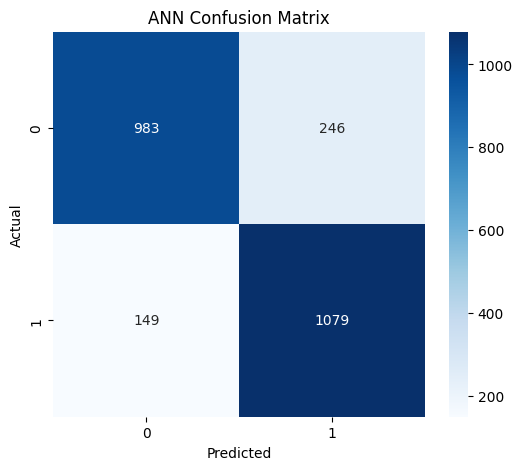

In [ ]:
cm = confusion_matrix(
    y_test,
    ann_test_pred
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("ANN Confusion Matrix")

plt.show()

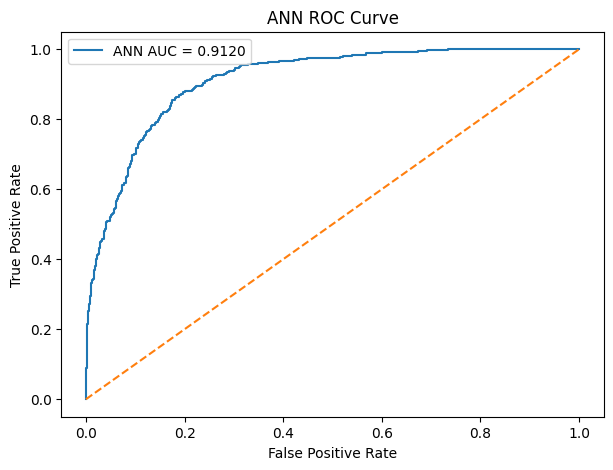

In [ ]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    ann_test_prob
)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"ANN AUC = {ann_auc:.4f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ANN ROC Curve")

plt.legend()
plt.show()

Validation loss

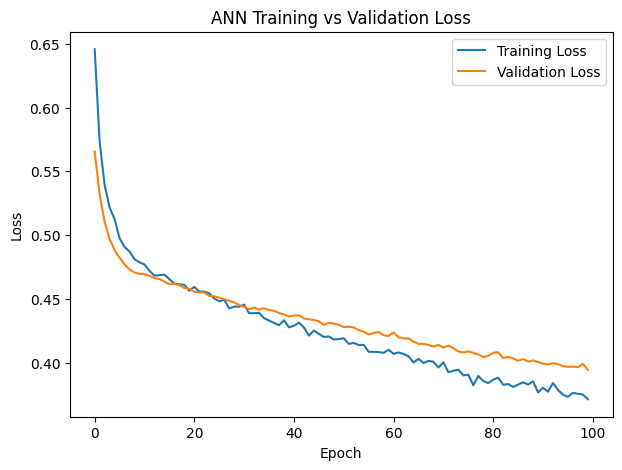

In [ ]:
best_history = ann_histories[
    best_ann_name
]

plt.figure(figsize=(7, 5))

plt.plot(
    best_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    best_history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ANN Training vs Validation Loss")

plt.legend()
plt.show()

In [ ]:
best_ann_model.save(
    "best_ann_model.keras"
)

ann_results_df.to_csv(
    "ann_model_comparison.csv",
    index=False
)

print("ANN model and results saved.")

ANN model and results saved.


In [ ]:
ann_final_result = pd.DataFrame([{
    "Model": "ANN",
    "Accuracy": ann_accuracy,
    "Precision": ann_precision,
    "Recall": ann_recall,
    "F1_Score": ann_f1,
    "ROC_AUC": ann_auc
}])

ann_final_result.to_csv(
    "ANN_final_result.csv",
    index=False
)
from google.colab import files
files.download("ANN_final_result.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>